## Methodology
1. Data Collection – Gathered the AI Job Trends Dataset (2024–2030) containing 30,000
records across 8 industries and 8 countries.
(“https://www.kaggle.com/datasets/sahilislam007/ai-impact-on-job-market-20242030”)
2. Data Preprocessing – Cleaned the dataset, handled missing values, and prepared data for
analysis.
3. Exploratory Data Analysis (EDA) – Analyzed job market trends, AI impact levels, automation
risk, and employment projections.
4. Data Visualization – Created charts and graphs to compare job openings, industry growth,
and automation risks.
5. Correlation Analysis – Examined relationships between AI impact, automation risk, salaries,
and job growth.
6. Machine Learning Modeling – Applied regression and classification models to predict future
job openings and job status.
7. Model Evaluation – Assessed model performance using standard evaluation metrics.
8. Dashboard Development – Built an interactive Streamlit/Power BI dashboard for real-time
exploration of AI-driven workforce trends.
9. Result Analysis – Interpreted findings and generated insights on the future impact of AI on
employment.

In [40]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [41]:
data = pd.read_csv('ai_job_trends_dataset2024-230.csv')
data.head()

,Job Title,Industry,Job Status,AI Impact Level,Median Salary (USD),Required Education,Experience Required (Years),Job Openings (2024),Projected Openings (2030),Remote Work Ratio (%),Automation Risk (%),Location,Gender Diversity (%)
0,Investment analyst,IT,Increasing,Moderate,42109.76,Master’s Degree,5,1515,6342,55.96,28.28,UK,44.63
1,"Journalist, newspaper",Manufacturing,Increasing,Moderate,132298.57,Master’s Degree,15,1243,6205,16.81,89.71,USA,66.39
2,Financial planner,Finance,Increasing,Low,143279.19,Bachelor’s Degree,4,3338,1154,91.82,72.97,Canada,41.13
3,Legal secretary,Healthcare,Increasing,High,97576.13,Associate Degree,15,7173,4060,1.89,99.94,Australia,65.76
4,Aeronautical engineer,IT,Increasing,Low,60956.63,Master’s Degree,13,5944,7396,53.76,37.65,Germany,72.57


In [42]:
data.shape

(30000, 13)

In [43]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 13 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Job Title                    30000 non-null  str    
 1   Industry                     30000 non-null  str    
 2   Job Status                   30000 non-null  str    
 3   AI Impact Level              30000 non-null  str    
 4   Median Salary (USD)          30000 non-null  float64
 5   Required Education           30000 non-null  str    
 6   Experience Required (Years)  30000 non-null  int64  
 7   Job Openings (2024)          30000 non-null  int64  
 8   Projected Openings (2030)    30000 non-null  int64  
 9   Remote Work Ratio (%)        30000 non-null  float64
 10  Automation Risk (%)          30000 non-null  float64
 11  Location                     30000 non-null  str    
 12  Gender Diversity (%)         30000 non-null  float64
dtypes: float64(4), int64(3), st

In [44]:
data.describe()

,Median Salary (USD),Experience Required (Years),Job Openings (2024),Projected Openings (2030),Remote Work Ratio (%),Automation Risk (%),Gender Diversity (%)
count,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000
mean,90119.965639,10.051433,5039.640833,5074.218100,49.836431,50.154229,49.979660
std,34412.013953,6.060678,2861.009654,2866.550722,28.966688,28.754889,17.274665
min,30001.860000,0.000000,100.000000,100.000000,0.000000,0.000000,20.000000
25%,60500.702500,5.000000,2570.000000,2586.750000,24.570000,25.400000,35.070000
50%,90274.115000,10.000000,5034.000000,5106.500000,49.570000,50.020000,49.885000
75%,119454.710000,15.000000,7527.000000,7573.000000,75.100000,75.030000,64.910000
max,149998.500000,20.000000,10000.000000,10000.000000,100.000000,99.990000,80.000000


In [45]:
data.columns

Index(['Job Title', 'Industry', 'Job Status', 'AI Impact Level',
       'Median Salary (USD)', 'Required Education',
       'Experience Required (Years)', 'Job Openings (2024)',
       'Projected Openings (2030)', 'Remote Work Ratio (%)',
       'Automation Risk (%)', 'Location', 'Gender Diversity (%)'],
      dtype='str')

In [46]:
data.isnull().sum()

Job Title                      0
Industry                       0
Job Status                     0
AI Impact Level                0
Median Salary (USD)            0
Required Education             0
Experience Required (Years)    0
Job Openings (2024)            0
Projected Openings (2030)      0
Remote Work Ratio (%)          0
Automation Risk (%)            0
Location                       0
Gender Diversity (%)           0
dtype: int64

In [47]:
data[data.isnull().any(axis=1)]

,Job Title,Industry,Job Status,AI Impact Level,Median Salary (USD),Required Education,Experience Required (Years),Job Openings (2024),Projected Openings (2030),Remote Work Ratio (%),Automation Risk (%),Location,Gender Diversity (%)


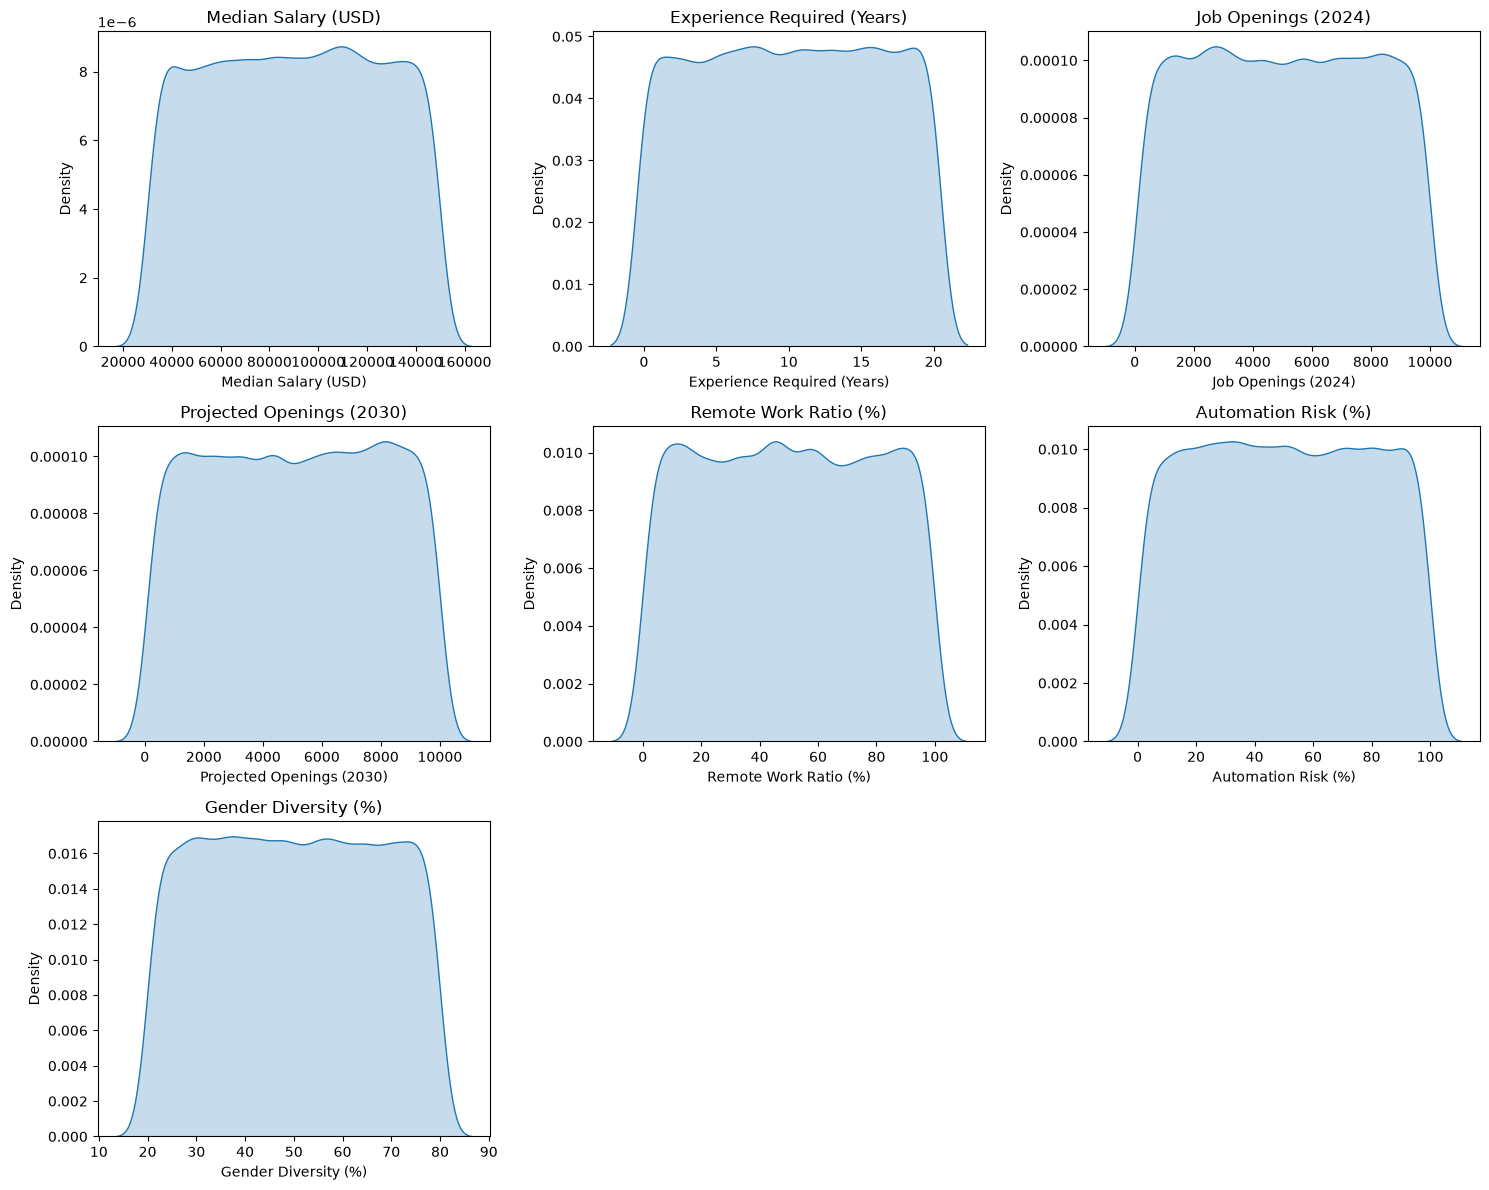

In [56]:
num_cols = [
    'Median Salary (USD)',
    'Experience Required (Years)',
    'Job Openings (2024)',
    'Projected Openings (2030)',
    'Remote Work Ratio (%)',
    'Automation Risk (%)',
    'Gender Diversity (%)'
]
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.kdeplot(data=data, x=col, fill=True, ax=axes[i])
    axes[i].set_title(col)

# Remove unused subplots
for j in range(len(num_cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

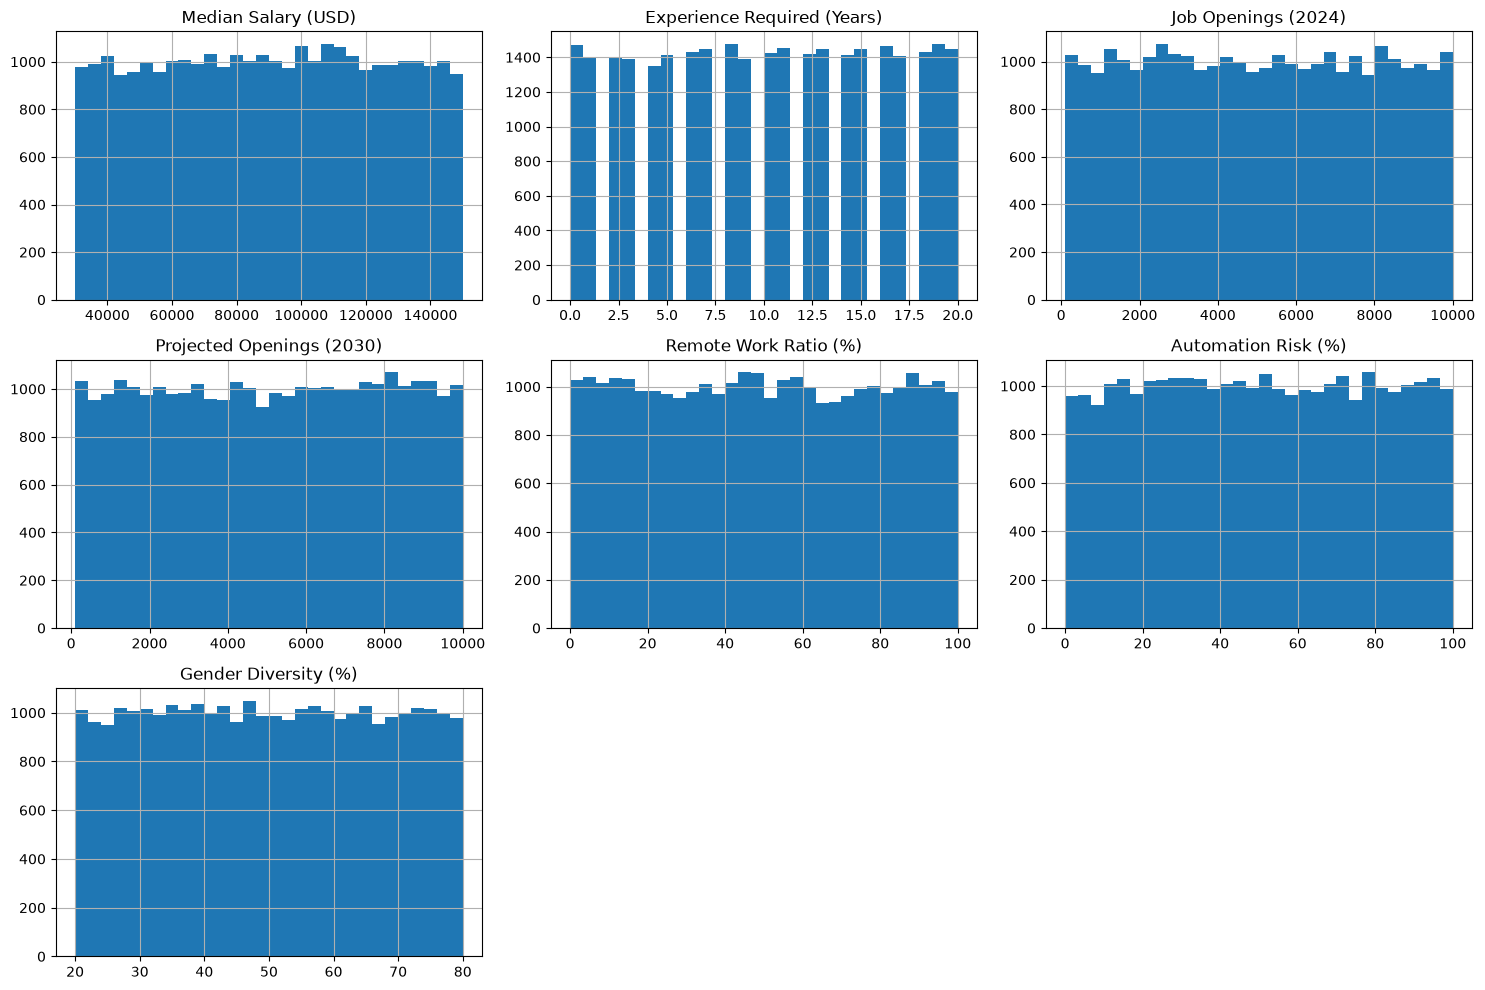

In [57]:
data[num_cols].hist(figsize=(15, 10), bins=30)
plt.tight_layout()
plt.show()

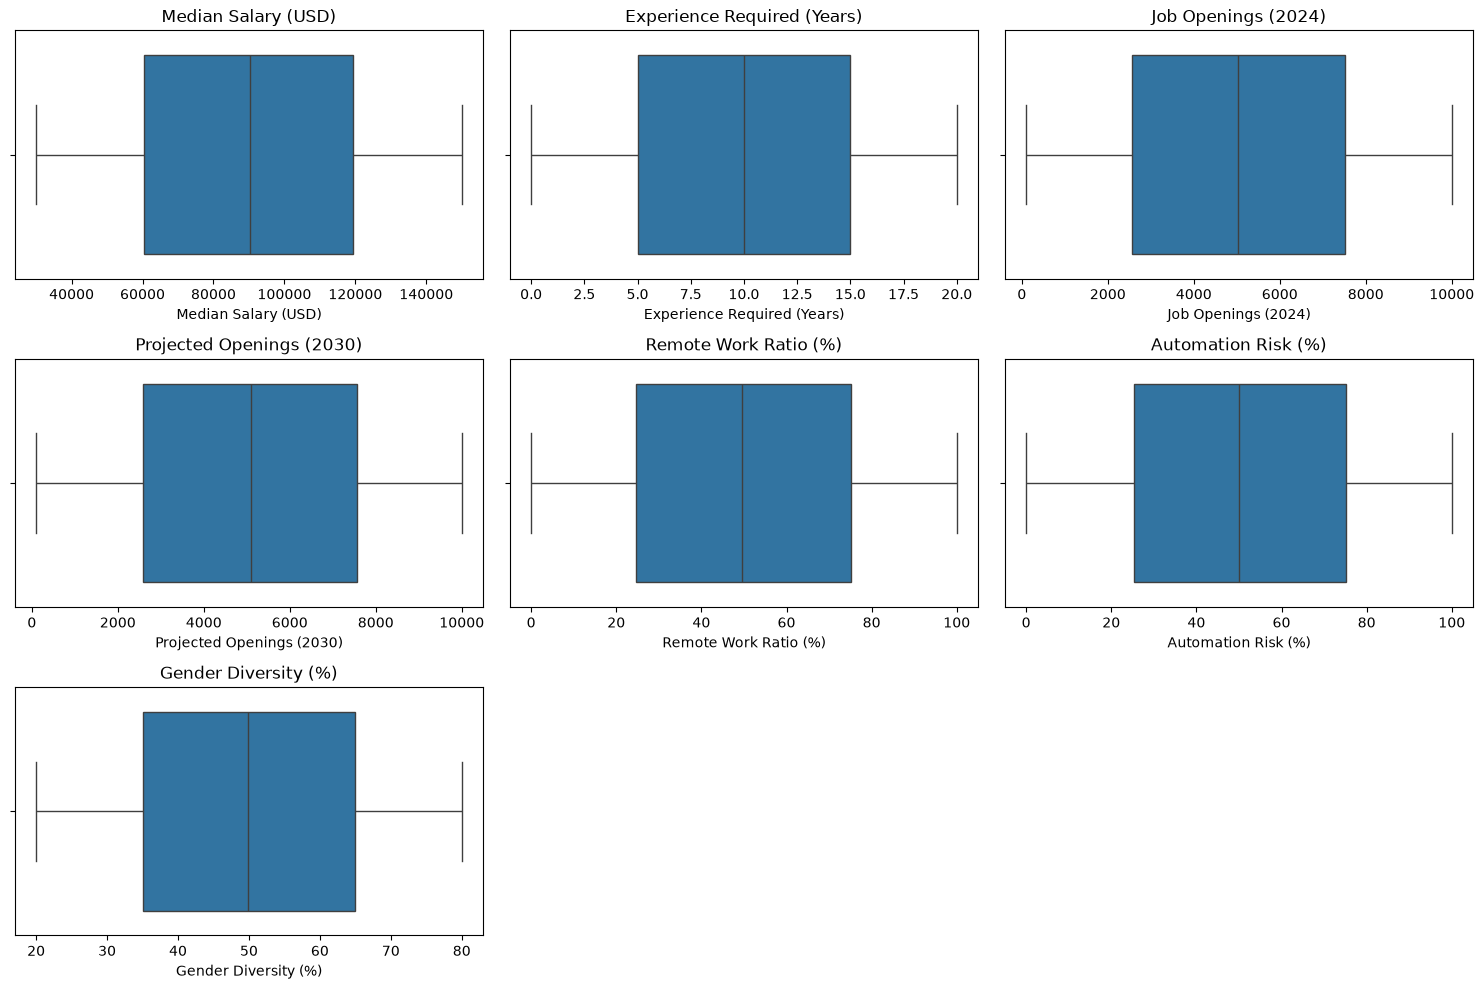

In [60]:
fig, axes = plt.subplots(3, 3, figsize=(15, 10))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.boxplot(x=data[col], ax=axes[i])
    axes[i].set_title(col)

for j in range(len(num_cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

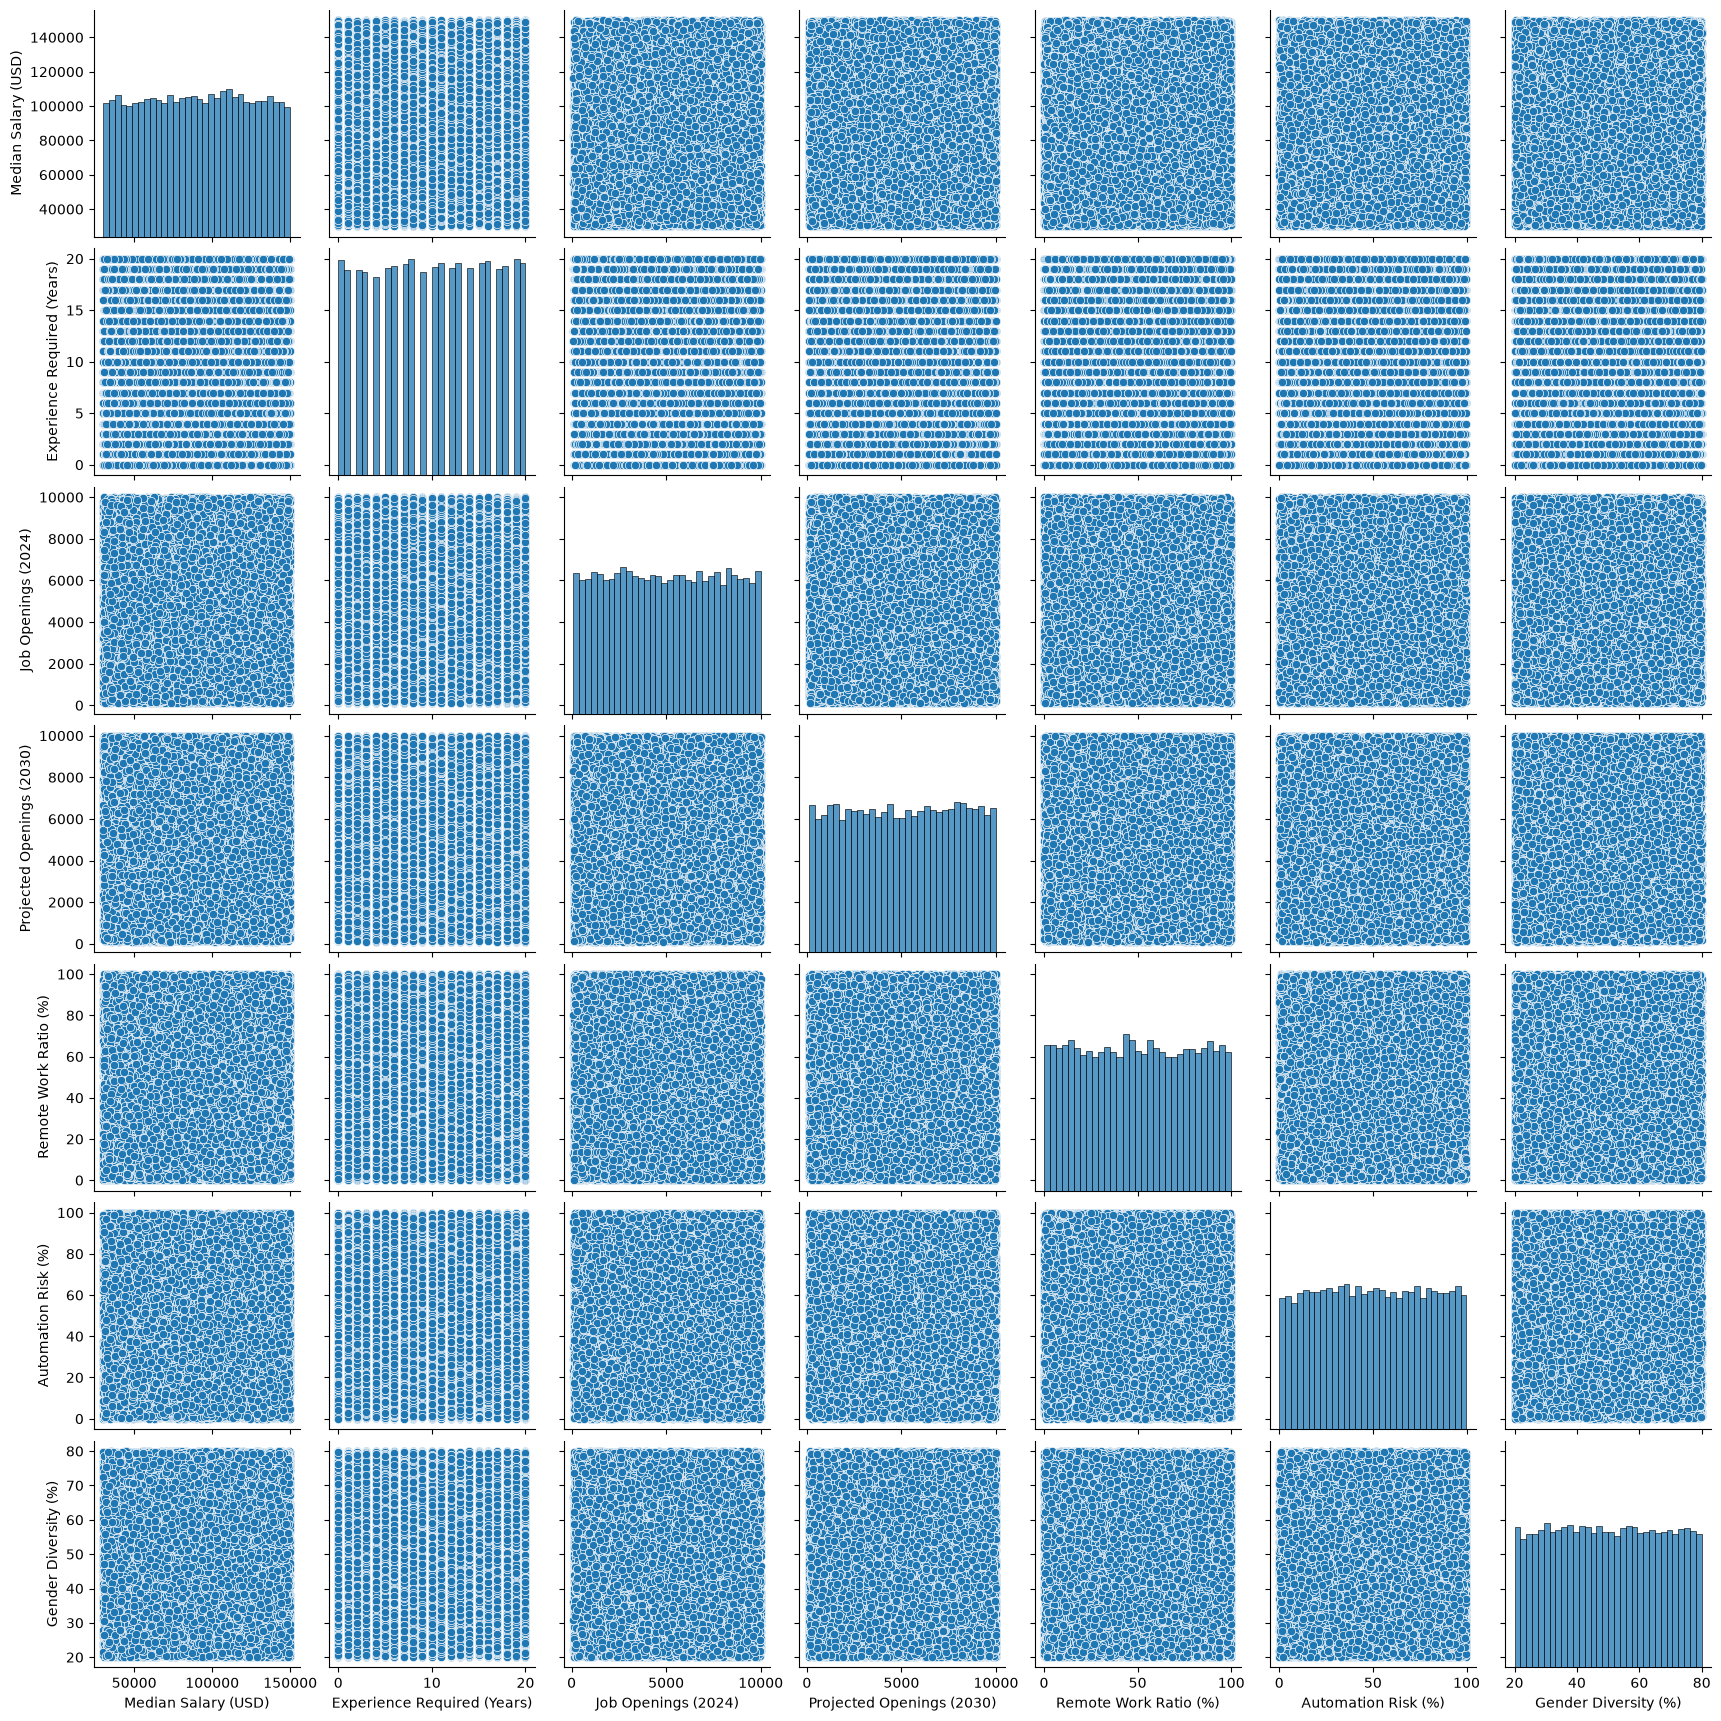

In [ ]:
sns.pairplot(data[num_cols])
plt.show()

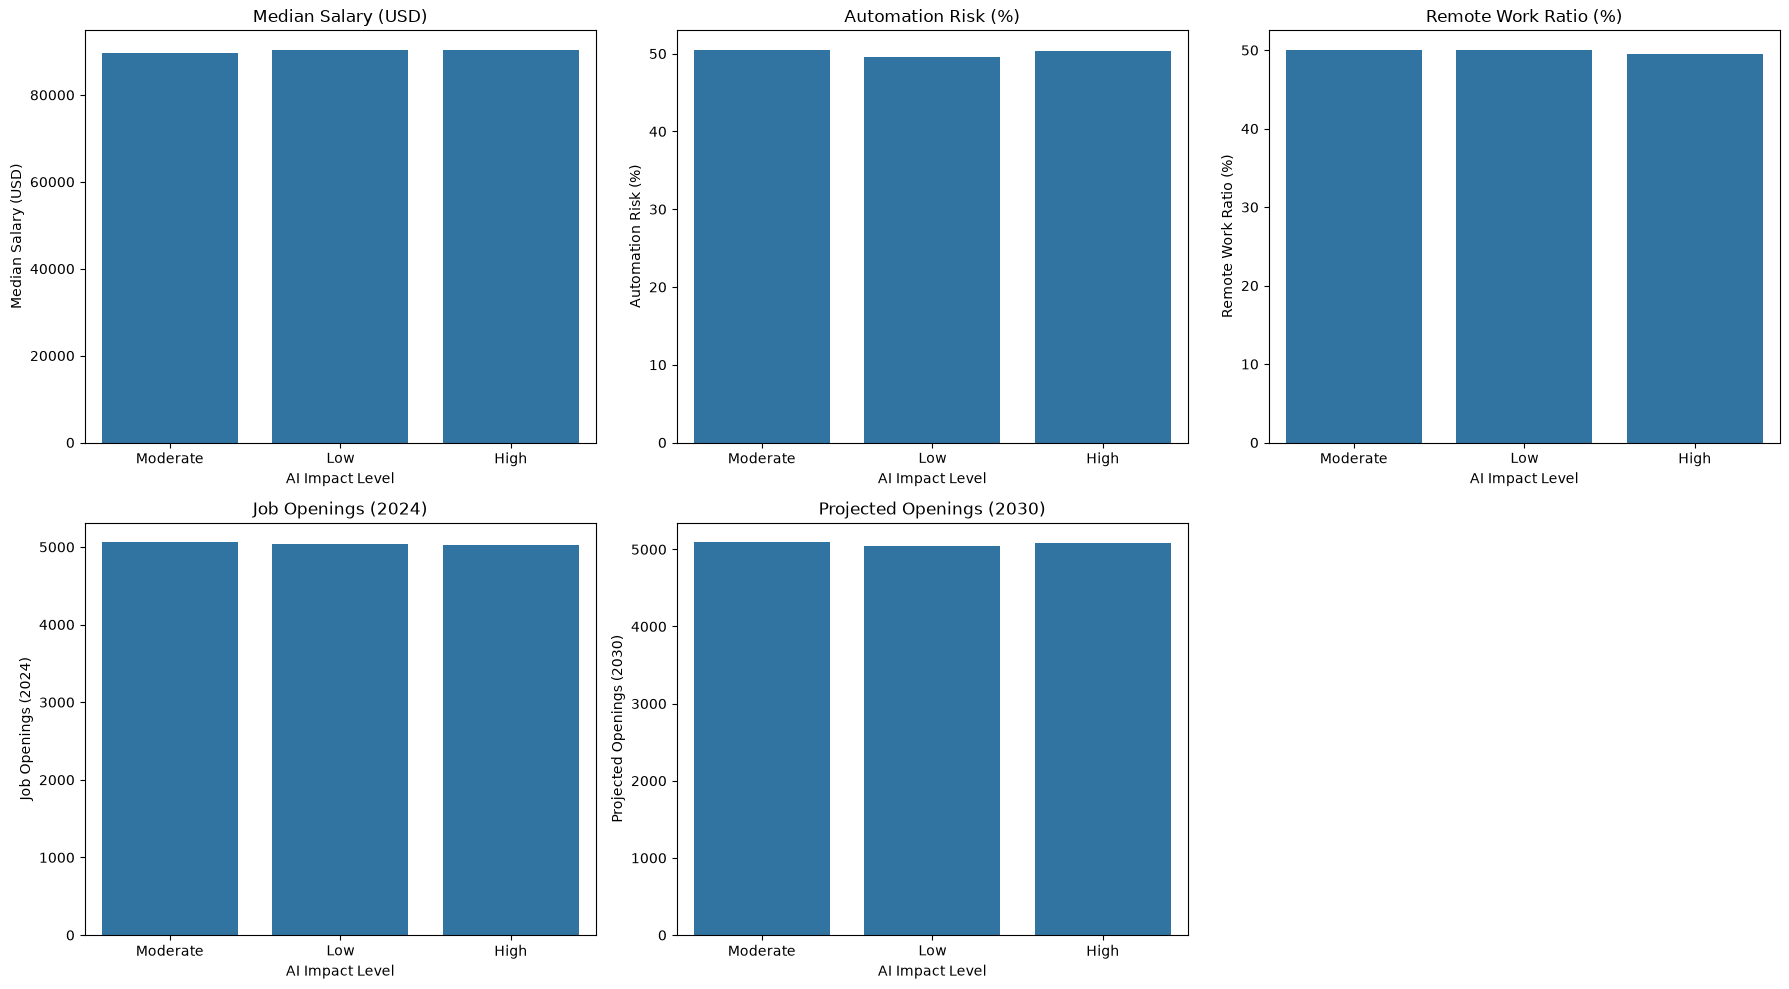

In [64]:
metrics = [
    'Median Salary (USD)',
    'Automation Risk (%)',
    'Remote Work Ratio (%)',
    'Job Openings (2024)',
    'Projected Openings (2030)'
]

fig, axes = plt.subplots(2, 3, figsize=(18,10))
axes = axes.flatten()

for i, col in enumerate(metrics):
    sns.barplot(
        data=data,
        x='AI Impact Level',
        y=col,
        estimator='mean',
        errorbar=None,
        ax=axes[i]
    )

    axes[i].set_title(col)
    axes[i].set_xlabel('AI Impact Level')

# Remove empty subplot
fig.delaxes(axes[5])

plt.tight_layout()
plt.show()

In [66]:
corr = data.corr(numeric_only=True)
corr

,Median Salary (USD),Experience Required (Years),Job Openings (2024),Projected Openings (2030),Remote Work Ratio (%),Automation Risk (%),Gender Diversity (%)
Median Salary (USD),1.000000,0.003302,-0.000803,-0.000230,-0.003844,0.007980,0.011688
Experience Required (Years),0.003302,1.000000,-0.001322,0.002285,0.007859,0.006541,-0.006006
Job Openings (2024),-0.000803,-0.001322,1.000000,-0.002536,-0.002111,0.003284,0.003733
Projected Openings (2030),-0.000230,0.002285,-0.002536,1.000000,-0.002334,0.007434,0.009539
Remote Work Ratio (%),-0.003844,0.007859,-0.002111,-0.002334,1.000000,0.004851,0.008988
Automation Risk (%),0.007980,0.006541,0.003284,0.007434,0.004851,1.000000,-0.003737
Gender Diversity (%),0.011688,-0.006006,0.003733,0.009539,0.008988,-0.003737,1.000000


<Axes: >

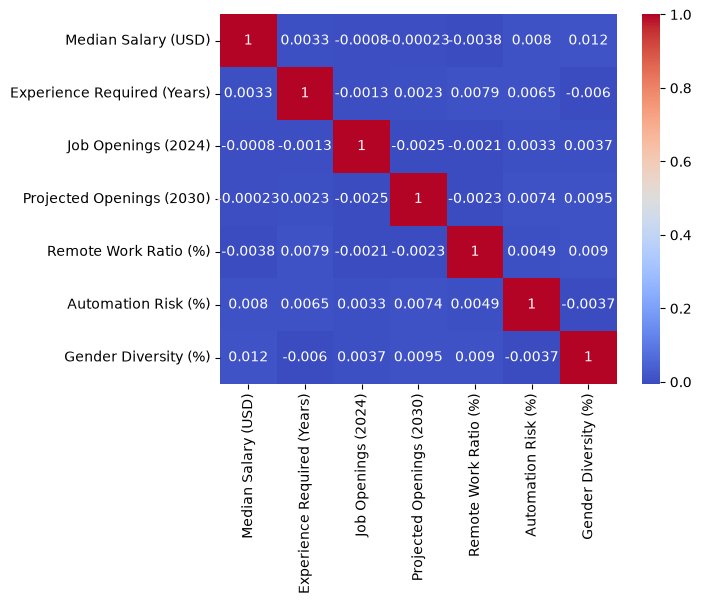

In [67]:
sns.heatmap(corr,
            annot=True,
            cmap='coolwarm')

In [68]:
data['Growth'] = (
    data['Projected Openings (2030)']
    - data['Job Openings (2024)']
)

In [69]:
data['Growth Rate (%)'] = (
    (data['Projected Openings (2030)'] - data['Job Openings (2024)'])
    / data['Job Openings (2024)']
) * 100

In [70]:
industry_growth = data.groupby('Industry')[
    ['Job Openings (2024)', 'Projected Openings (2030)']
].mean().round(2)

industry_growth

,Job Openings (2024),Projected Openings (2030)
Industry,,
Education,5047.85,5022.84
Entertainment,5046.22,5145.46
Finance,5032.59,5043.12
Healthcare,5041.51,5148.47
IT,4976.86,5115.90
Manufacturing,5082.45,5085.69
Retail,4958.10,5017.85
Transportation,5130.05,5008.69


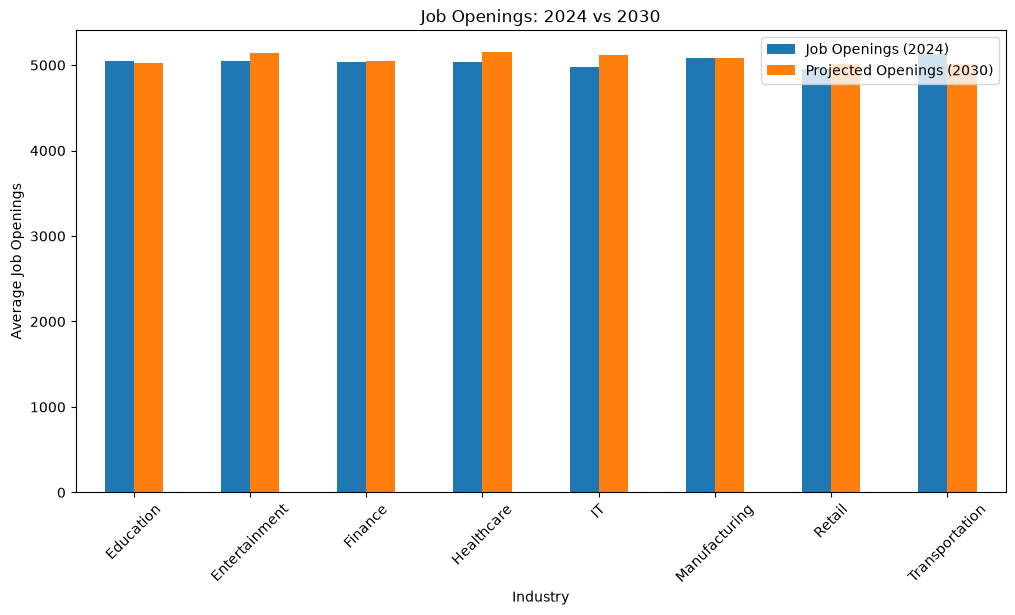

In [71]:
industry_growth.plot(
    kind='bar',
    figsize=(12,6)
)

plt.title("Job Openings: 2024 vs 2030")
plt.ylabel("Average Job Openings")
plt.xticks(rotation=45)
plt.legend(title="")
plt.show()

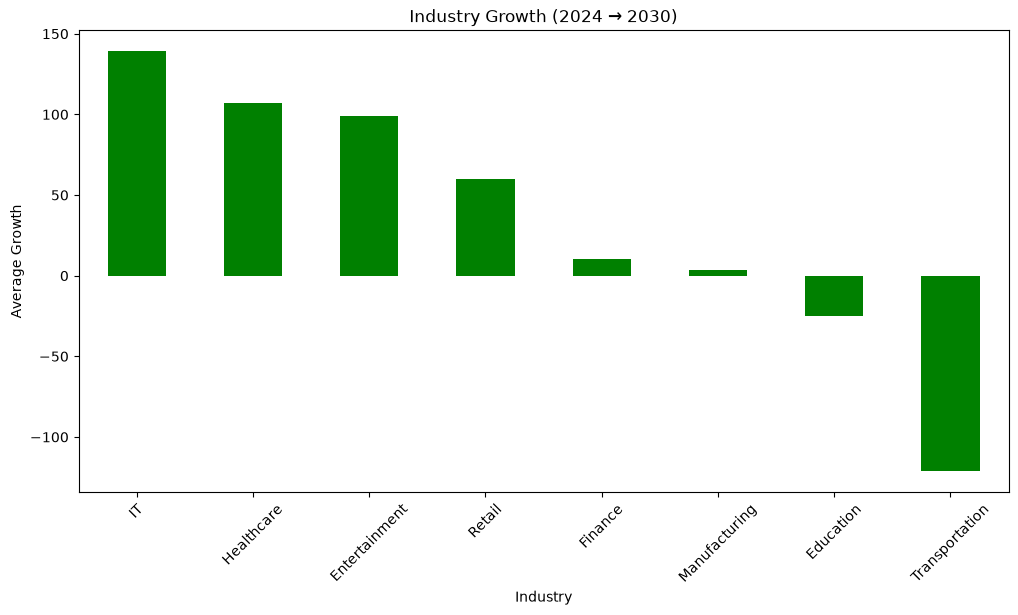

In [74]:
growth = data.groupby('Industry')['Growth'].mean()
growth.sort_values(ascending=False).plot(
    kind='bar',
    figsize=(12,6),
    color='green'
)

plt.title("Industry Growth (2024 → 2030)")
plt.ylabel("Average Growth")
plt.xticks(rotation=45)
plt.show()

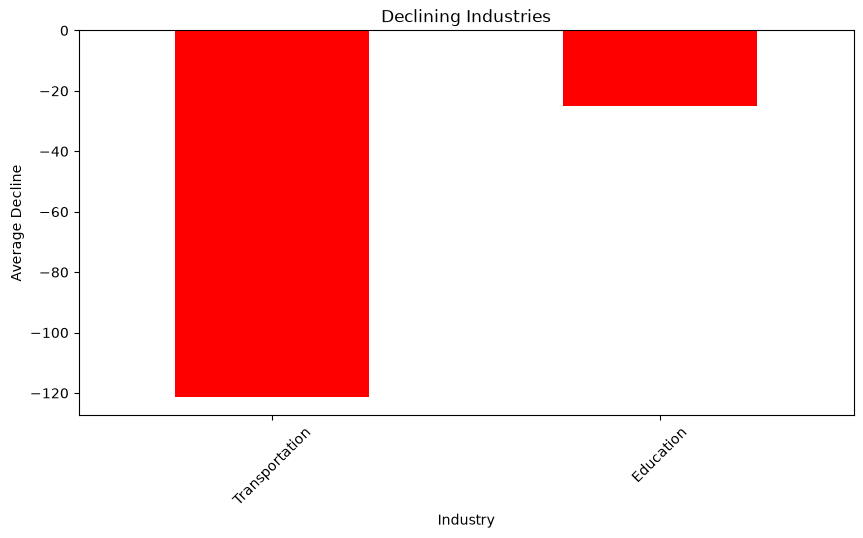

In [75]:
declining = growth[growth<0]
declining.sort_values().plot(
    kind='bar',
    figsize=(10,5),
    color='red'
)

plt.title("Declining Industries")
plt.ylabel("Average Decline")
plt.xticks(rotation=45)
plt.show()

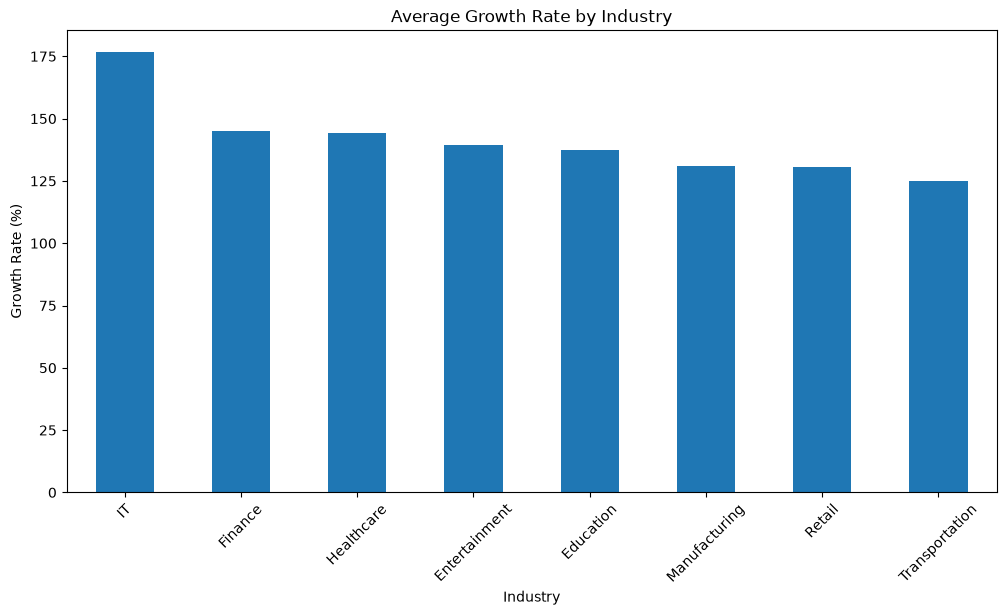

In [76]:
growth_rate = data.groupby('Industry')['Growth Rate (%)'].mean()
growth_rate.sort_values(ascending=False).plot(
    kind='bar',
    figsize=(12,6)
)

plt.title("Average Growth Rate by Industry")
plt.ylabel("Growth Rate (%)")
plt.xticks(rotation=45)
plt.show()